# PyTorch 기반 나선형(Spiral) 다중 분류 실습

이 노트북은 **나선형으로 섞여 있는 3개 클래스 데이터를 신경망으로 분류하는 실습 코드**입니다.

기존 코드의 목적은 다음과 같습니다.

- 선형 분류기로는 구분하기 어려운 나선형 데이터를 생성합니다.
- PyTorch의 `nn.Module`, `nn.Sequential`, `CrossEntropyLoss`, `Adam`을 사용하여 다중 분류 신경망을 학습합니다.
- 학습된 모델이 복잡한 비선형 결정 경계를 학습할 수 있는지 확인합니다.




In [1]:
# ============================================================
# 1. 기본 라이브러리 불러오기
# ============================================================

# NumPy는 수치 계산과 배열 생성을 위해 사용하는 라이브러리입니다.
# 여기서는 나선형 데이터셋을 직접 만들기 위해 사용합니다.
import numpy as np

# PyTorch는 딥러닝 모델을 만들고 학습시키기 위한 핵심 라이브러리입니다.
import torch

# torch.nn은 신경망 계층, 손실 함수 등을 제공하는 모듈입니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 최적화 알고리즘을 제공하는 모듈입니다.
import torch.optim as optim

# matplotlib은 데이터와 학습 결과를 시각화하기 위해 사용하는 라이브러리입니다.
import matplotlib.pyplot as plt

# Jupyter Notebook 또는 Google Colab에서 그래프가 셀 아래에 바로 표시되도록 설정합니다.
%matplotlib inline

# 실행 환경에 GPU가 있으면 cuda를 사용하고, 없으면 cpu를 사용합니다.
# 이렇게 작성하면 CPU 환경과 GPU 환경 모두에서 코드가 오류 없이 실행됩니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 사용 중인 연산 장치를 출력합니다.
print("현재 사용 장치:", device)

# 난수 고정은 매번 실행할 때 비슷한 결과가 나오도록 하기 위한 설정입니다.
# 실습과 강의에서는 결과 재현이 중요하므로 seed를 고정하는 것이 좋습니다.
np.random.seed(42)
torch.manual_seed(42)

# GPU를 사용하는 경우에도 난수를 고정합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


현재 사용 장치: cpu


## 2. 나선형 데이터셋 생성

이 실습에서는 일반적인 직선 분류로는 구분하기 어려운 **Spiral Dataset**을 사용합니다.

나선형 데이터는 클래스들이 서로 말려 들어간 형태이기 때문에, 단순한 선형 모델로는 정확하게 분류하기 어렵습니다. 따라서 은닉층과 활성화 함수를 가진 신경망이 필요한 대표적인 예제입니다.


In [2]:
# ============================================================
# 2. 나선형 데이터셋 생성
# ============================================================

# N은 각 클래스마다 생성할 데이터 개수입니다.
# 여기서는 클래스 1개당 100개씩 생성합니다.
N = 100

# D는 입력 데이터의 차원 수입니다.
# 2차원 좌표 데이터이므로 x좌표와 y좌표, 총 2개의 입력 특징을 가집니다.
D = 2

# K는 클래스 개수입니다.
# 여기서는 3개의 나선형 클래스를 분류하는 문제입니다.
K = 3

# X는 전체 입력 데이터를 저장할 배열입니다.
# 전체 데이터 개수는 N * K = 300개이고, 각 데이터는 2차원 좌표를 가집니다.
X = np.zeros((N * K, D), dtype=np.float32)

# y는 각 데이터의 정답 클래스 번호를 저장할 배열입니다.
# 클래스 번호는 0, 1, 2로 저장됩니다.
y = np.zeros(N * K, dtype=np.int64)

# 3개의 클래스를 반복하면서 각 클래스에 해당하는 나선형 데이터를 생성합니다.
for j in range(K):
    # ix는 현재 클래스 j에 해당하는 데이터의 인덱스 범위입니다.
    # 예: j=0이면 0~99, j=1이면 100~199, j=2이면 200~299입니다.
    ix = range(N * j, N * (j + 1))

    # r은 원점에서부터 바깥쪽으로 점점 커지는 반지름 값입니다.
    # 0에서 1까지 N개 값을 생성합니다.
    r = np.linspace(0.0, 1, N)

    # t는 각도(theta)를 의미합니다.
    # 클래스마다 다른 각도 범위를 사용하여 서로 다른 나선 형태를 만듭니다.
    # np.random.randn(N) * 0.2는 약간의 잡음을 추가하여 데이터를 더 현실적으로 만듭니다.
    t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N) * 0.2

    # 극좌표 r, t를 2차원 직교좌표 x, y로 변환합니다.
    # 첫 번째 열은 x좌표, 두 번째 열은 y좌표가 됩니다.
    X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]

    # 현재 인덱스 범위의 정답 라벨을 클래스 번호 j로 지정합니다.
    y[ix] = j

# 생성된 입력 데이터의 형태를 출력합니다.
print("입력 데이터 X 형태:", X.shape)

# 생성된 정답 라벨의 형태를 출력합니다.
print("정답 라벨 y 형태:", y.shape)

# 각 클래스의 데이터 개수를 출력합니다.
print("클래스별 데이터 개수:", np.bincount(y))


입력 데이터 X 형태: (300, 2)
정답 라벨 y 형태: (300,)
클래스별 데이터 개수: [100 100 100]


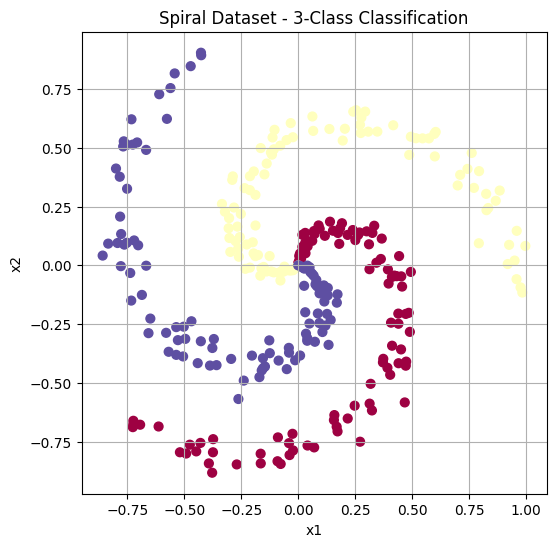

In [3]:
# ============================================================
# 3. 생성된 나선형 데이터 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(6, 6))

# X[:, 0]은 x좌표, X[:, 1]은 y좌표입니다.
# c=y는 클래스 번호에 따라 점의 색을 다르게 표시하라는 의미입니다.
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)

# 그래프 제목을 설정합니다.
plt.title("Spiral Dataset - 3-Class Classification")

# x축 이름을 설정합니다.
plt.xlabel("x1")

# y축 이름을 설정합니다.
plt.ylabel("x2")

# 그래프 격자를 표시합니다.
plt.grid(True)

# 그래프를 화면에 출력합니다.
plt.show()


## 4. NumPy 데이터를 PyTorch Tensor로 변환

PyTorch 모델은 NumPy 배열을 직접 학습할 수 없습니다. 따라서 입력 데이터 `X`와 정답 라벨 `y`를 PyTorch Tensor로 변환해야 합니다.

다중 분류 문제에서 입력 데이터는 `FloatTensor`, 정답 라벨은 `LongTensor` 형식이어야 합니다. 특히 `nn.CrossEntropyLoss()`는 정답 라벨을 클래스 번호 형태의 `LongTensor`로 요구합니다.


In [4]:
# ============================================================
# 4. NumPy 배열을 PyTorch Tensor로 변환
# ============================================================

# 입력 데이터 X를 PyTorch FloatTensor로 변환합니다.
# 딥러닝 모델의 입력값은 일반적으로 실수형 float32를 사용합니다.
x_tensor = torch.from_numpy(X).float()

# 정답 라벨 y를 PyTorch LongTensor로 변환합니다.
# CrossEntropyLoss는 정답 라벨을 0, 1, 2 같은 정수 클래스 번호로 받습니다.
y_tensor = torch.from_numpy(y).long()

# Tensor를 연산 장치로 이동합니다.
# GPU가 있으면 GPU로 이동하고, 없으면 CPU에 그대로 둡니다.
x_tensor = x_tensor.to(device)
y_tensor = y_tensor.to(device)

# 변환된 Tensor의 크기를 출력합니다.
print("x_tensor 크기:", x_tensor.size())

# 정답 라벨 Tensor의 크기를 출력합니다.
print("y_tensor 크기:", y_tensor.size())

# 입력 Tensor의 데이터 타입을 출력합니다.
print("x_tensor 자료형:", x_tensor.dtype)

# 정답 Tensor의 데이터 타입을 출력합니다.
print("y_tensor 자료형:", y_tensor.dtype)


x_tensor 크기: torch.Size([300, 2])
y_tensor 크기: torch.Size([300])
x_tensor 자료형: torch.float32
y_tensor 자료형: torch.int64


## 5. 신경망 모델 구성

나선형 데이터는 직선 하나로 분류하기 어렵기 때문에, 여러 개의 은닉층과 ReLU 활성화 함수를 가진 다층 신경망을 사용합니다.

모델 구조는 다음과 같습니다.

```text
입력층 2개
 ↓
은닉층 20개 뉴런 + ReLU
 ↓
은닉층 10개 뉴런 + ReLU
 ↓
은닉층 5개 뉴런 + ReLU
 ↓
은닉층 5개 뉴런 + ReLU
 ↓
출력층 3개
```

출력층이 3개인 이유는 클래스가 3개이기 때문입니다. `CrossEntropyLoss`를 사용할 때는 출력층에 `Softmax`를 직접 붙이지 않습니다. PyTorch의 `CrossEntropyLoss` 내부에서 Softmax 역할을 포함하여 계산하기 때문입니다.


In [5]:
# ============================================================
# 5. PyTorch 신경망 모델 정의
# ============================================================

# nn.Sequential은 여러 계층을 순서대로 쌓아서 모델을 만드는 방식입니다.
# 입력 데이터는 위에서 아래 방향으로 각 계층을 순서대로 통과합니다.
model = nn.Sequential(

    # 첫 번째 완전연결층입니다.
    # 입력 특징 2개를 받아서 은닉 뉴런 20개로 변환합니다.
    nn.Linear(2, 20),

    # ReLU 활성화 함수입니다.
    # 음수는 0으로 바꾸고, 양수는 그대로 통과시켜 비선형성을 추가합니다.
    nn.ReLU(),

    # 두 번째 완전연결층입니다.
    # 20개의 은닉 출력을 10개의 은닉 출력으로 변환합니다.
    nn.Linear(20, 10),

    # 두 번째 ReLU 활성화 함수입니다.
    nn.ReLU(),

    # 세 번째 완전연결층입니다.
    # 10개의 은닉 출력을 5개의 은닉 출력으로 변환합니다.
    nn.Linear(10, 5),

    # 세 번째 ReLU 활성화 함수입니다.
    nn.ReLU(),

    # 네 번째 완전연결층입니다.
    # 5개의 은닉 출력을 다시 5개의 은닉 출력으로 변환합니다.
    nn.Linear(5, 5),

    # 네 번째 ReLU 활성화 함수입니다.
    nn.ReLU(),

    # 출력층입니다.
    # 최종적으로 3개 클래스에 대한 점수(logit)를 출력합니다.
    # 클래스가 3개이므로 출력 뉴런도 3개입니다.
    nn.Linear(5, 3)
)

# 모델을 현재 연산 장치로 이동합니다.
model = model.to(device)

# 모델 구조를 출력합니다.
print(model)


Sequential(
  (0): Linear(in_features=2, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=5, bias=True)
  (5): ReLU()
  (6): Linear(in_features=5, out_features=5, bias=True)
  (7): ReLU()
  (8): Linear(in_features=5, out_features=3, bias=True)
)


In [6]:
# ============================================================
# 6. 손실 함수와 최적화 알고리즘 설정
# ============================================================

# CrossEntropyLoss는 다중 분류 문제에서 가장 많이 사용하는 손실 함수입니다.
# 모델 출력값은 클래스별 점수(logits)이고, 정답은 클래스 번호입니다.
loss_func = nn.CrossEntropyLoss()

# Adam Optimizer는 학습률을 자동으로 조정하면서 빠르게 학습하도록 도와주는 최적화 알고리즘입니다.
# model.parameters()는 모델 안의 모든 학습 가능한 가중치와 편향을 의미합니다.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 전체 학습 반복 횟수입니다.
# epoch가 클수록 모델이 데이터를 더 많이 반복해서 학습합니다.
num_epoch = 10000

print("손실 함수:", loss_func)
print("최적화 알고리즘:", optimizer)
print("학습 반복 횟수:", num_epoch)


손실 함수: CrossEntropyLoss()
최적화 알고리즘: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
학습 반복 횟수: 10000


## 7. 모델 학습

학습 과정은 다음 순서로 진행됩니다.

1. 모델이 입력 데이터를 보고 예측값을 계산합니다.
2. 예측값과 실제 정답을 비교하여 손실값을 계산합니다.
3. 이전 단계에서 누적된 기울기를 초기화합니다.
4. 역전파를 수행하여 각 가중치와 편향의 기울기를 계산합니다.
5. Optimizer가 계산된 기울기를 이용하여 가중치와 편향을 수정합니다.

이 과정이 반복되면서 모델은 나선형 데이터의 복잡한 경계를 점점 더 잘 학습하게 됩니다.


In [7]:
# ============================================================
# 7. 신경망 모델 학습
# ============================================================

# 학습 과정에서 손실값과 정확도를 저장하기 위한 리스트입니다.
loss_history = []
accuracy_history = []

# num_epoch만큼 반복하여 모델을 학습합니다.
for epoch in range(num_epoch):

    # --------------------------------------------------------
    # 1단계. 순전파(Forward Propagation)
    # --------------------------------------------------------
    # 모델에 입력 데이터를 넣어 각 클래스에 대한 예측 점수를 계산합니다.
    output = model(x_tensor)

    # --------------------------------------------------------
    # 2단계. 손실값 계산
    # --------------------------------------------------------
    # CrossEntropyLoss를 이용하여 예측값과 정답 라벨 사이의 오차를 계산합니다.
    loss = loss_func(output, y_tensor)

    # --------------------------------------------------------
    # 3단계. 이전 Gradient 초기화
    # --------------------------------------------------------
    # PyTorch는 기본적으로 gradient를 누적하므로, 매 반복마다 반드시 초기화해야 합니다.
    optimizer.zero_grad()

    # --------------------------------------------------------
    # 4단계. 역전파(Backpropagation)
    # --------------------------------------------------------
    # 손실값을 기준으로 모든 가중치와 편향에 대한 gradient를 계산합니다.
    loss.backward()

    # --------------------------------------------------------
    # 5단계. 가중치와 편향 업데이트
    # --------------------------------------------------------
    # Adam Optimizer가 계산된 gradient를 이용하여 모델 파라미터를 수정합니다.
    optimizer.step()

    # --------------------------------------------------------
    # 6단계. 학습 기록 저장
    # --------------------------------------------------------
    # loss.item()은 Tensor 형태의 손실값을 Python 숫자로 변환합니다.
    loss_history.append(loss.item())

    # 예측 점수 중 가장 큰 값의 인덱스를 예측 클래스로 선택합니다.
    pred = torch.argmax(output, dim=1)

    # 예측 클래스와 실제 정답이 같은 비율을 정확도로 계산합니다.
    acc = (pred == y_tensor).float().mean().item()

    # 정확도 기록을 저장합니다.
    accuracy_history.append(acc)

    # 500번마다 현재 학습 상태를 출력합니다.
    if epoch % 500 == 0:
        print(f"Epoch [{epoch:5d}/{num_epoch}] | Loss: {loss.item():.6f} | Accuracy: {acc:.4f}")

# 최종 학습 결과를 출력합니다.
print("최종 손실값:", loss_history[-1])
print("최종 정확도:", accuracy_history[-1])


Epoch [    0/10000] | Loss: 1.152041 | Accuracy: 0.3333
Epoch [  500/10000] | Loss: 0.375452 | Accuracy: 0.9367
Epoch [ 1000/10000] | Loss: 0.144569 | Accuracy: 0.9767
Epoch [ 1500/10000] | Loss: 0.081090 | Accuracy: 0.9900
Epoch [ 2000/10000] | Loss: 0.052234 | Accuracy: 0.9933
Epoch [ 2500/10000] | Loss: 0.037315 | Accuracy: 0.9933
Epoch [ 3000/10000] | Loss: 0.029047 | Accuracy: 0.9933
Epoch [ 3500/10000] | Loss: 0.023793 | Accuracy: 0.9933
Epoch [ 4000/10000] | Loss: 0.020256 | Accuracy: 0.9933
Epoch [ 4500/10000] | Loss: 0.017781 | Accuracy: 0.9933
Epoch [ 5000/10000] | Loss: 0.016041 | Accuracy: 0.9933
Epoch [ 5500/10000] | Loss: 0.014790 | Accuracy: 0.9933
Epoch [ 6000/10000] | Loss: 0.013888 | Accuracy: 0.9933
Epoch [ 6500/10000] | Loss: 0.013224 | Accuracy: 0.9933
Epoch [ 7000/10000] | Loss: 0.012720 | Accuracy: 0.9933
Epoch [ 7500/10000] | Loss: 0.012326 | Accuracy: 0.9933
Epoch [ 8000/10000] | Loss: 0.012029 | Accuracy: 0.9933
Epoch [ 8500/10000] | Loss: 0.011813 | Accuracy:

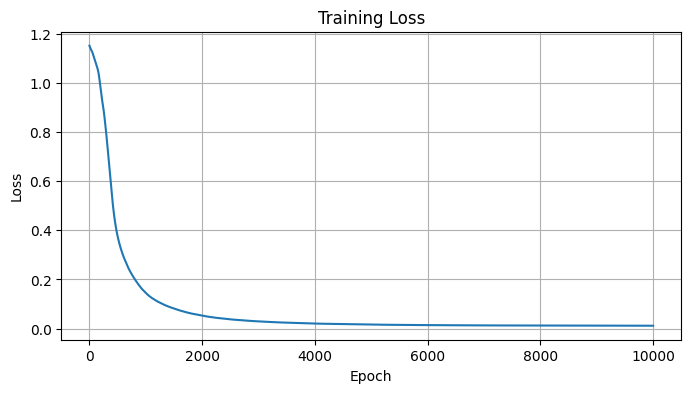

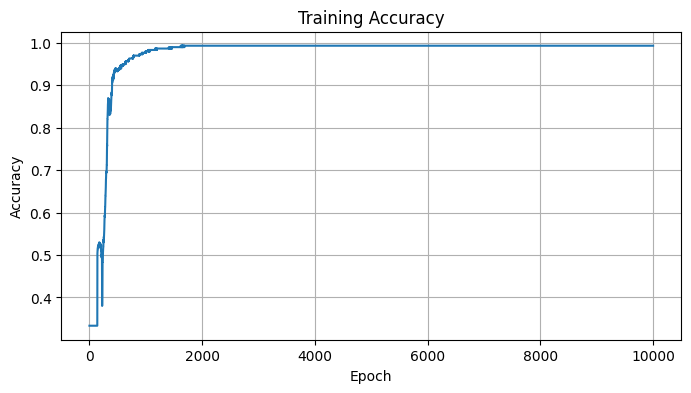

In [8]:
# ============================================================
# 8. 학습 손실과 정확도 변화 시각화
# ============================================================

# 손실 그래프를 그립니다.
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 정확도 그래프를 그립니다.
plt.figure(figsize=(8, 4))
plt.plot(accuracy_history)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


## 9. 모델 예측 결과 확인

학습이 끝난 후 모델이 전체 데이터를 얼마나 잘 분류하는지 확인합니다.

다중 분류에서는 출력층이 클래스 개수만큼 값을 냅니다. 이 값들은 확률이 아니라 `logit`이라고 부르는 점수입니다. 따라서 가장 큰 점수를 가진 위치를 선택하면 최종 예측 클래스가 됩니다.


In [9]:
# ============================================================
# 9. 최종 예측 결과 확인
# ============================================================

# torch.no_grad()는 평가 단계에서 gradient 계산을 비활성화합니다.
# 평가할 때는 역전파가 필요 없으므로 메모리 사용량이 줄고 속도가 빨라집니다.
with torch.no_grad():

    # 전체 입력 데이터에 대한 모델 출력을 계산합니다.
    final_output = model(x_tensor)

    # 각 데이터마다 가장 높은 점수를 가진 클래스를 예측 결과로 선택합니다.
    final_pred = torch.argmax(final_output, dim=1)

    # 전체 정확도를 계산합니다.
    final_acc = (final_pred == y_tensor).float().mean().item()

# 최종 정확도를 출력합니다.
print(f"최종 학습 정확도: {final_acc:.4f}")

# 앞의 10개 데이터에 대한 예측 결과와 실제 정답을 비교해서 출력합니다.
print("앞의 10개 예측 결과:", final_pred[:10].cpu().numpy())
print("앞의 10개 실제 정답:", y_tensor[:10].cpu().numpy())


최종 학습 정확도: 0.9933
앞의 10개 예측 결과: [0 0 0 0 0 0 0 0 0 0]
앞의 10개 실제 정답: [0 0 0 0 0 0 0 0 0 0]


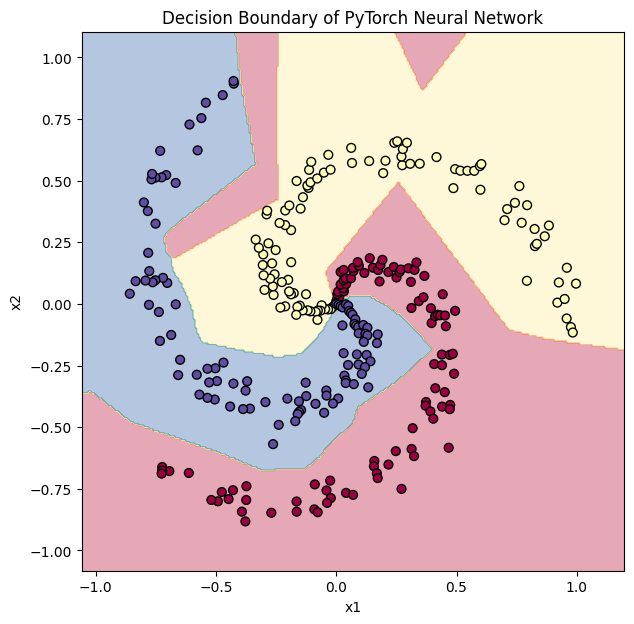

In [10]:
# ============================================================
# 10. 결정 경계(Decision Boundary) 시각화
# ============================================================

# 결정 경계는 모델이 어떤 영역을 어떤 클래스로 판단하는지 보여주는 그림입니다.
# 나선형 데이터에서는 결정 경계가 직선이 아니라 복잡한 곡선 형태로 나타나야 합니다.

# x축과 y축의 최소/최대 범위를 설정합니다.
x_min, x_max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
y_min, y_max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2

# 결정 경계를 촘촘히 그리기 위해 격자 좌표를 생성합니다.
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# 격자 좌표를 모델 입력 형태인 [데이터 개수, 2] 형태로 변환합니다.
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

# NumPy 배열을 PyTorch Tensor로 변환하고 연산 장치로 이동합니다.
grid_tensor = torch.from_numpy(grid).float().to(device)

# 평가 모드에서 격자 좌표 전체에 대한 예측을 수행합니다.
with torch.no_grad():

    # 모델 출력값을 계산합니다.
    grid_output = model(grid_tensor)

    # 가장 높은 점수를 가진 클래스를 예측 클래스로 선택합니다.
    grid_pred = torch.argmax(grid_output, dim=1)

    # 시각화를 위해 CPU로 이동한 뒤 NumPy 배열로 변환합니다.
    Z = grid_pred.cpu().numpy()

# 격자의 예측 결과를 원래 meshgrid 형태로 변환합니다.
Z = Z.reshape(xx.shape)

# 결정 경계 그래프 크기를 설정합니다.
plt.figure(figsize=(7, 7))

# contourf는 배경 영역을 클래스별 색으로 채워서 결정 경계를 보여줍니다.
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Spectral)

# 실제 데이터를 점으로 표시합니다.
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral, edgecolors="k")

# 그래프 제목을 설정합니다.
plt.title("Decision Boundary of PyTorch Neural Network")

# x축 이름을 설정합니다.
plt.xlabel("x1")

# y축 이름을 설정합니다.
plt.ylabel("x2")

# 그래프를 출력합니다.
plt.show()


In [11]:
# ============================================================
# 11. 학습된 Weight와 Bias 확인
# ============================================================

# 모델의 각 층에 저장된 가중치와 편향을 확인합니다.
# DNN에서는 입력 하나당 weight가 하나만 있는 것이 아니라,
# 각 층의 뉴런 연결 수만큼 많은 weight가 존재합니다.

for name, param in model.named_parameters():

    # 파라미터 이름을 출력합니다.
    # 예: 0.weight, 0.bias, 2.weight, 2.bias ...
    print("파라미터 이름:", name)

    # 파라미터의 형태를 출력합니다.
    print("파라미터 형태:", param.shape)

    # 실제 값을 일부만 출력합니다.
    print(param.data[:5])

    # 구분선을 출력합니다.
    print("-" * 60)


파라미터 이름: 0.weight
파라미터 형태: torch.Size([20, 2])
tensor([[ 0.4236,  0.7780],
        [ 0.3949,  2.6556],
        [-0.2760,  0.4591],
        [-0.4301,  2.1943],
        [ 1.5665, -2.3619]])
------------------------------------------------------------
파라미터 이름: 0.bias
파라미터 형태: torch.Size([20])
tensor([0.8344, 0.0214, 1.0094, 1.1206, 1.1958])
------------------------------------------------------------
파라미터 이름: 2.weight
파라미터 형태: torch.Size([10, 20])
tensor([[ 7.1750e-01,  1.0267e+00,  4.3008e-01,  5.8623e-01,  3.2127e-01,
          2.2840e+00,  1.0177e+00,  2.9350e-01,  6.7462e-01, -1.3337e-01,
          2.0112e-01, -1.5438e+00, -9.5466e-01, -1.8252e-01, -4.8282e-02,
         -1.9604e-02,  4.4288e-01,  1.1417e+00,  8.5862e-01,  1.8580e-01],
        [-5.9363e-03, -2.0588e-01,  8.3350e-01,  4.7134e-01,  2.7695e-01,
         -1.9704e+00,  1.4769e-02,  1.5366e-01, -3.2055e-01,  6.8172e-02,
          4.7272e-02,  1.1473e+00,  8.1771e-01,  6.8106e-01, -1.0230e+00,
          2.3228e-01,  2.9564e-0

## 12. 코드 전체 정리

이 노트북은 다음 과정을 수행합니다.

1. 나선형 다중 분류 데이터를 직접 생성했습니다.
2. 데이터를 PyTorch Tensor로 변환했습니다.
3. `nn.Sequential`을 사용하여 다층 신경망을 구성했습니다.
4. `CrossEntropyLoss`를 사용하여 다중 분류 손실을 계산했습니다.
5. `Adam` Optimizer를 사용하여 가중치와 편향을 업데이트했습니다.
6. 학습 손실과 정확도를 그래프로 확인했습니다.
7. 학습된 모델의 결정 경계를 시각화했습니다.
8. 학습된 Weight와 Bias를 확인했습니다.

이 코드는 단순한 선형 모델로는 해결하기 어려운 데이터를 신경망이 어떻게 비선형적으로 분류하는지 보여주기 위한 실습 코드입니다.
